# Rainbow Six Siege player-match analysis

Source: `assets/playersmatches_test.csv`. The six sections cover dataset scope, quality,
player win/loss and K/D distributions, maximum streaks, additional player features and a
proposal for training a churn model.

Run from the repository root with the dependencies in `requirements.txt`. Section 5 refreshes the
existing `outputs/players_features.csv`.

In [73]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("assets/playersmatches_test.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
assert DATA_PATH.exists(), f"Run this notebook from the repo root; {DATA_PATH} not found."

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

# One palette for the whole notebook, so a colour always means the same thing.
BLUE, ORANGE, GREEN, VERMILLION = "#0072B2", "#E69F00", "#009E73", "#D55E00"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "legend.fontsize": 8,
})

## 1. Dataset and scope

I start with the source schema, the unit represented by a row, and the period covered.

In [74]:
df = pd.read_csv(DATA_PATH)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns\n")
print(df.dtypes.to_string())
df.drop(columns=["teammateid", "opponentid"]).head(3)

95,734 rows x 11 columns

playerid                 str
matchid                  str
gamemode                 str
victory                  str
kills                float64
death                float64
match_datetime           str
playernb_in_match      int64
still_active            bool
teammateid               str
opponentid               str


,playerid,matchid,gamemode,victory,kills,death,match_datetime,playernb_in_match,still_active
0,00f2d75c-7aeb-465b-8d82-7085837cade3,7c5bf406-e736-4faf-9ad3-d0212ecef357,PVP,false,0.0,3.0,2025-06-11T05:45:08.995Z,11,True
1,10c31731-4ea8-477b-bcf3-8b3424f956e9,006fd414-9d56-4c5c-bec4-1e177f4012d3,PVP,false,4.0,3.0,2025-09-24T13:23:27.592Z,10,False
2,10c31731-4ea8-477b-bcf3-8b3424f956e9,0199977b-f28e-4518-a20b-6b3bbb4a3abf,PVP,true,6.0,4.0,2025-09-24T13:36:40.815Z,11,False


`kills` and `death` are floating-point columns because some combat statistics are missing.
`victory` contains strings rather than a boolean; Section 2 checks all its values. `still_active`
parses as a boolean, but its definition and assessment date are not supplied.

I parse the timestamps in UTC and map only `true` and `false` to decided outcomes.

In [75]:
ORIGINAL_COLUMNS = list(df.columns)

df["match_ts"] = pd.to_datetime(df["match_datetime"], format="ISO8601", utc=True)
df["match_date"] = df["match_ts"].dt.date
df["is_win"] = df["victory"].map({"true": 1.0, "false": 0.0})

print("first recorded timestamp:", df["match_ts"].min())
print("last recorded timestamp :", df["match_ts"].max())
print("span                    :", (df["match_ts"].max() - df["match_ts"].min()).days, "days")

first recorded timestamp: 2025-03-04 15:04:17.034000+00:00
last recorded timestamp : 2026-03-03 13:54:20.190000+00:00
span                    : 363 days


In [76]:
grain = pd.Series({
    "rows": len(df),
    "distinct playerid": df["playerid"].nunique(),
    "distinct matchid": df["matchid"].nunique(),
    "duplicated (playerid, matchid) pairs": df.duplicated(["playerid", "matchid"]).sum(),
    "fully duplicated rows": df.duplicated().sum(),
    "matchid appearing more than once": (df["matchid"].value_counts() > 1).sum(),
})
grain.to_frame("value")

,value
rows,95734
distinct playerid,840
distinct matchid,95723
"duplicated (playerid, matchid) pairs",0
fully duplicated rows,0
matchid appearing more than once,11


There are **95,734 rows, 840 tracked players and 95,723 distinct match IDs**, with no duplicate
`(playerid, matchid)` pairs or full rows. One row describes one tracked player's participation in a
match: outcome, combat statistics, mode, timestamp and anonymised teammate/opponent lists.

Only 11 matches appear twice. This is a player-centric sample, rather than a complete record of
every participant in each match. The roster IDs give wider context, but those players' full
histories are unavailable. I check how many referenced IDs also belong to the tracked cohort.

In [77]:
def roster_ids(series: pd.Series) -> pd.Series:
    # Explode a comma-separated id column into one id per row, dropping blanks.
    exploded = series.fillna("").str.split(",").explode()
    return exploded[(exploded != "") & (exploded != "null")]

teammates = roster_ids(df["teammateid"])
opponents = roster_ids(df["opponentid"])
referenced = pd.concat([teammates, opponents])

cohort = set(df["playerid"])
referenced_unique = set(referenced.unique())

print(f"roster slots filled              : {len(referenced):,}")
print(f"distinct players referenced      : {len(referenced_unique):,}")
print(f"...of which are in our 840 cohort: {len(referenced_unique & cohort)}")

roster slots filled              : 908,600
distinct players referenced      : 710,282
...of which are in our 840 cohort: 21


The rosters reference about **710,000 distinct IDs**, of which only **21** are among the 840
tracked players. The sampling method is unknown, so these players cannot be assumed representative
of r6s's whole player base. The extract also does not establish that their histories are complete.

In [78]:
print("Recorded modes:")
print(df["gamemode"].value_counts().to_frame("rows").assign(
    share_pct=lambda d: (d["rows"] / len(df) * 100).round(2)).to_string(), "\n")

matches_per_player = df.groupby("playerid").size()
print("Matches per tracked player:")
print(matches_per_player.describe().round(1).to_string(), "\n")

label = df.groupby("playerid")["still_active"].first()
print("Supplied still_active flag:")
print(label.value_counts().to_frame("players").assign(
    share_pct=lambda d: (d["players"] / len(label) * 100).round(1)).to_string())

Recorded modes:
               rows  share_pct
gamemode                      
PVP_RANKED    48563      50.73
PVP           32267      33.70
PVP_UNRANKED  14899      15.56
OPERATIONS        5       0.01 

Matches per tracked player:
count     840.0
mean      114.0
std       214.3
min         1.0
25%         5.0
50%        27.5
75%       111.2
max      1974.0 

Supplied still_active flag:
              players  share_pct
still_active                    
False             488       58.1
True              352       41.9


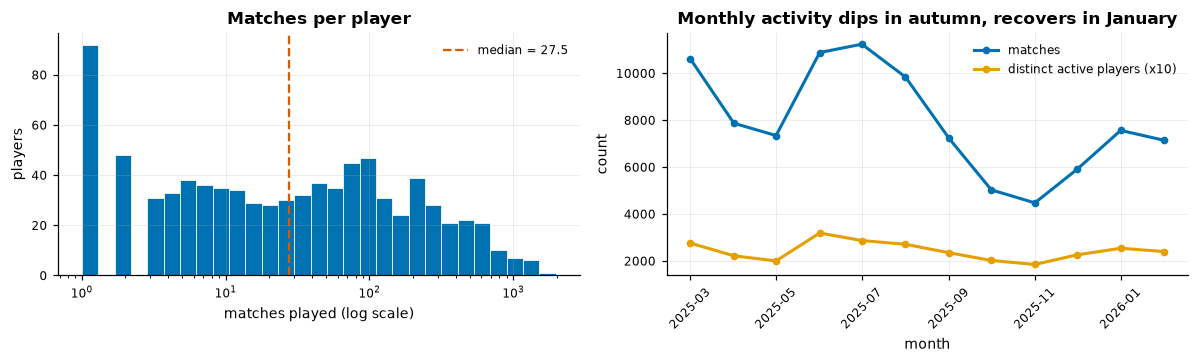

Players included in activity histogram: 840


,matches,players,matches_per_active_player
match_ts,,,
2025-03-01 00:00:00+00:00,10617,276,38.5
2025-04-01 00:00:00+00:00,7869,222,35.4
2025-05-01 00:00:00+00:00,7346,200,36.7
2025-06-01 00:00:00+00:00,10884,319,34.1
2025-07-01 00:00:00+00:00,11240,287,39.2
2025-08-01 00:00:00+00:00,9839,271,36.3
2025-09-01 00:00:00+00:00,7223,235,30.7
2025-10-01 00:00:00+00:00,5031,202,24.9
2025-11-01 00:00:00+00:00,4475,185,24.2


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# Left: how much activity each player contributes. Log x, because the spread is huge.
bins = np.logspace(0, np.log10(matches_per_player.max()), 30)
bins[-1] = matches_per_player.max()  # include the maximum in the final bin
activity_hist_counts, _, _ = axes[0].hist(
    matches_per_player, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5
)
axes[0].set_xscale("log")
axes[0].axvline(matches_per_player.median(), color=VERMILLION, linestyle="--", linewidth=1.5,
                label=f"median = {matches_per_player.median():.1f}")
axes[0].set(title="Matches per player",
            xlabel="matches played (log scale)", ylabel="players")
axes[0].legend()

# Right: volume over time, to check the window is evenly covered.
monthly = df.resample("MS", on="match_ts").agg(
    matches=("matchid", "size"), players=("playerid", "nunique"))
axes[1].plot(monthly.index[:-1], monthly["matches"].iloc[:-1], color=BLUE, linewidth=2, marker="o", markersize=4,
             label="matches")
axes[1].plot(monthly.index[:-1], monthly["players"].iloc[:-1] * 10, color=ORANGE, linewidth=2, marker="o",
             markersize=4, label="distinct active players (x10)")
axes[1].set(title="Monthly activity dips in autumn, recovers in January", xlabel="month",
            ylabel="count")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

print(f"Players included in activity histogram: {int(activity_hist_counts.sum())}")
monthly.assign(matches_per_active_player=lambda d: (d["matches"] / d["players"]).round(1))

The extract covers **4 March 2025 to 3 March 2026**. Ranked accounts for 50.7% of rows, PVP for
33.7%, Unranked for 15.6%, and OPERATIONS for five rows. Activity is uneven: the median player has
27.5 matches, the mean is 114 and the maximum is 1,974. The supplied flag identifies 352 players
as active and 488 as inactive (58.1%); this is not yet a defined churn rate.

Recorded match volume peaks around 11,200 in July, dips to about 4,500 in November, and recovers to
about 7,600 in January. Matches per monthly active player **fluctuate**: 38.5 in March, 35.4 in April,
36.7 in May, 39.2 in July, 24.2 in November and 29.8 in January. The monthly player populations
differ, so this does not show that the same remaining players reduced their activity.

Seasonality is one possible explanation for the dip and recovery, but one annual cycle cannot
establish it. These monthly totals do not locate individual churn dates. March 2025 starts on the
4th, and March 2026 covers only three days; I omit the latter from the line chart and retain it in
the table. The player-count line is scaled by ten and labelled accordingly.

## 2. Data quality

I check missing values, outcome categories, roster consistency, shared matches and timestamp
ordering. Unusual values need a field definition before I can decide whether they are errors.

### Missing data and outcomes

In [80]:
source = df[ORIGINAL_COLUMNS]
missing = pd.DataFrame({
    "missing": source.isna().sum(),
    "missing_pct": (source.isna().mean() * 100).round(3),
})
print(missing[missing["missing"] > 0].to_string(), "\n")

stats_missing = df["kills"].isna()
print("Kills and deaths have identical missingness:", stats_missing.equals(df["death"].isna()))
print("Affected players:", df.loc[stats_missing, "playerid"].nunique())
print("Missing combat rows by outcome:", df.loc[stats_missing, "victory"].value_counts().to_dict())
print("Missing combat rows by mode:", df.loc[stats_missing, "gamemode"].value_counts().to_dict())

print("\nEmpty roster columns by recorded context:")
print(df.loc[df["teammateid"].isna() | df["opponentid"].isna()]
      .assign(missing_teammates=lambda d: d["teammateid"].isna(),
              missing_opponents=lambda d: d["opponentid"].isna())
      .groupby(["gamemode", "playernb_in_match"])[["missing_teammates", "missing_opponents"]]
      .sum().to_string())

            missing  missing_pct
kills           153        0.160
death           153        0.160
teammateid        6        0.006
opponentid       11        0.011 

Kills and deaths have identical missingness: True
Affected players: 43
Missing combat rows by outcome: {'true': 78, 'false': 75}
Missing combat rows by mode: {'PVP_RANKED': 80, 'PVP': 46, 'PVP_UNRANKED': 27}

Empty roster columns by recorded context:
                                missing_teammates  missing_opponents
gamemode     playernb_in_match                                      
OPERATIONS   1                                  5                  5
PVP          5                                  0                  4
PVP_RANKED   5                                  0                  1
PVP_UNRANKED 1                                  1                  1


Combat statistics are missing together on **153 rows (0.16%) across 43 players**: 78 victories
and 75 defeats, spread across Ranked (80), PVP (46) and Unranked (27). The missingness mechanism is
unknown. The six empty teammate lists occur on one-participant records. There are 11 empty
opponent lists: five OPERATIONS, one solo Unranked and five other PvP records. Their meaning needs
clarification.

I retain these rows for outcome and activity calculations, and leave their combat values missing.
Because kills and deaths are missing together, replacing both with zero would not change aggregate
K/D for players with observed statistics. It would lower per-match averages and misrepresent
coverage. I use observed combat rows for averages and `sum(min_count=1)` for totals, so entirely
unobserved totals stay missing.

In [81]:
print("victory values:")
print(df["victory"].value_counts().to_frame("rows").assign(
    share_pct=lambda d: (d["rows"] / len(df) * 100).round(3)).to_string(), "\n")

odd_outcomes = df["victory"].isin(["draw", "other"])
print("where the non-boolean outcomes occur:")
print(pd.crosstab(df.loc[odd_outcomes, "victory"], df.loc[odd_outcomes, "gamemode"]).to_string())

victory values:
          rows  share_pct
victory                  
false    49761     51.978
true     45917     47.963
draw        43      0.045
other       13      0.014 

where the non-boolean outcomes occur:
gamemode  OPERATIONS  PVP  PVP_RANKED  PVP_UNRANKED
victory                                            
draw               0    8          27             8
other              2    6           4             1


There are **45,917 `true`, 49,761 `false`, 43 `draw` and 13 `other`** outcomes. Draws are unusual
for classic objective playlists: Ubisoft removed drawn-round outcomes in
[Phantom Sight](https://www.ubisoft.com/en-ca/game/rainbow-six/siege/news-updates/seasons/phantomsight).
These telemetry values do not establish ordinary drawn matches. `other` could include aborted
matches, but that is a possible explanation rather than a confirmed definition.

I count only `true` as a win and `false` as a loss. `draw` and `other` are excluded from
decided-match denominators and break both victory and defeat streaks. This avoids treating
every non-win as a defeat.

### Rosters and shared matches

In [82]:
flags_per_player = df.groupby("playerid")["still_active"].nunique()
print(f"players whose still_active is not constant: {(flags_per_player > 1).sum()} / {len(flags_per_player)}")


def count_ids(series: pd.Series) -> pd.Series:
    # Count comma-separated IDs, treating an empty list as zero.
    cleaned = series.fillna("").replace("null", "")
    return cleaned.str.count(",").add(1).where(cleaned != "", 0).astype(int)


n_teammates = count_ids(df["teammateid"])
n_opponents = count_ids(df["opponentid"])

roster_total = 1 + n_teammates + n_opponents
print(f"rows where 1 + teammates + opponents != playernb_in_match: "
      f"{(roster_total != df['playernb_in_match']).sum()}")

full_roster = df["teammateid"].fillna("") + "," + df["opponentid"].fillna("")
self_listed = sum(pid in roster for pid, roster in zip(df["playerid"], full_roster))
print(f"rows where the player appears in their own roster       : {self_listed}")

players whose still_active is not constant: 0 / 840
rows where 1 + teammates + opponents != playernb_in_match: 0
rows where the player appears in their own roster       : 0


In [83]:
balance = pd.DataFrame({"own_team": n_teammates + 1, "opposing_team": n_opponents})
print("Most common recorded roster sizes:")
print(balance.value_counts().head(5).to_frame("rows").to_string())
print(f"\nEqual-sized recorded rosters: "
      f"{(balance['own_team'] == balance['opposing_team']).mean():.1%}")

mode_ranges = df.groupby("gamemode").agg(
    max_recorded_participants=("playernb_in_match", "max"),
    max_recorded_deaths=("death", "max"),
)
mode_ranges["rows_above_10_participants"] = (
    df["playernb_in_match"].gt(10).groupby(df["gamemode"]).sum()
)
print("\nRanges by recorded mode:")
print(mode_ranges.to_string())

six_vs_six = (balance["own_team"] == 6) & (balance["opposing_team"] == 6)
print("\nEarliest recorded 6v6 roster:", df.loc[six_vs_six, "match_ts"].min())

Most common recorded roster sizes:
                         rows
own_team opposing_team       
5        5              70000
6        5               4372
5        6               3725
7        5               2266
5        4               2046

Equal-sized recorded rosters: 75.6%

Ranges by recorded mode:
              max_recorded_participants  max_recorded_deaths  rows_above_10_participants
gamemode                                                                                
OPERATIONS                            1                  1.0                           0
PVP                                  25                  5.0                       21667
PVP_RANKED                           10                  9.0                           0
PVP_UNRANKED                         10                  9.0                           0

Earliest recorded 6v6 roster: 2025-03-04 22:56:01.069000+00:00


The roster arithmetic holds on every row: `1 + teammates + opponents = playernb_in_match`,
and the tracked player never appears in their own lists. **75.6% have equal-sized recorded rosters**;
this does not establish that teams stayed balanced throughout play.

All **21,667 rows above ten participants occur in PVP**; Ranked and Unranked never exceed ten.
If PVP denotes Quick Match, this supports a backfilling explanation: the lists may retain players
who left alongside replacements who joined later. That could produce more than ten cumulative
participants without oversized teams playing simultaneously. The precise field definition and
playlist-code mapping still need confirmation.

Classic Siege uses 5v5 teams, but that is not universal. Ubisoft's
[March 2025 Siege X announcement](https://news.ubisoft.com/en-us/article/55e9bGaVCdO52trbclOhpf/rainbow-six-siege-x-showcase-everything-you-need-to-know)
describes Dual Front, launched on **10 June 2025**, as 6v6 with respawns.

In [84]:
shared_ids = df["matchid"].value_counts().loc[lambda s: s > 1].index
checks = []


def relation(seen_by, other):
    mates = seen_by["teammateid"] if isinstance(seen_by["teammateid"], str) else ""
    foes = seen_by["opponentid"] if isinstance(seen_by["opponentid"], str) else ""
    if other["playerid"] in mates.split(","):
        return "teammate"
    if other["playerid"] in foes.split(","):
        return "opponent"
    return "absent"


for match_id, pair in df[df["matchid"].isin(shared_ids)].groupby("matchid"):
    a, b = pair.iloc[0], pair.iloc[1]
    rel = relation(a, b)
    # Expected agreement only under a team-result interpretation of victory.
    agrees_with_team_result = ((a["victory"] != b["victory"]) if rel == "opponent"
                              else (a["victory"] == b["victory"]))
    checks.append({
        "matchid": match_id[:8],
        "mode": a["gamemode"],
        "A_sees_B": rel,
        "B_sees_A": relation(b, a),
        "victory_A": a["victory"],
        "victory_B": b["victory"],
        "agrees_with_team_result": agrees_with_team_result,
        "timestamp_gap_s": round(abs((a["match_ts"] - b["match_ts"]).total_seconds()), 1),
    })

shared_check = pd.DataFrame(checks)
print("Shared matches:", len(shared_check))
print("Reciprocal teammate/opponent relationships:",
      shared_check["A_sees_B"].eq(shared_check["B_sees_A"]).all()
      and shared_check["A_sees_B"].isin(["teammate", "opponent"]).all())
print("Timestamp differences (seconds):",
      shared_check["timestamp_gap_s"].min(), "to", shared_check["timestamp_gap_s"].max())
shared_check.loc[~shared_check["agrees_with_team_result"]]

Shared matches: 11
Reciprocal teammate/opponent relationships: True
Timestamp differences (seconds): 0.3 to 366.6


,matchid,mode,A_sees_B,B_sees_A,victory_A,victory_B,agrees_with_team_result,timestamp_gap_s
7,da011e60,PVP_UNRANKED,teammate,teammate,true,false,False,4.3


All 11 shared matches have reciprocal roster relationships. In Unranked match `da011e60`,
recorded teammates have different outcomes: a **potential inconsistency** if `victory` means
the team result. Ubisoft's earlier
[matchmaking documentation](https://www.ubisoft.com/en-us/game/rainbow-six/siege/news-updates/4hShcX2HZTG2ttIi3IIN9Y/matchmaking-rating)
describes personal Ranked losses for abandoning even when the team wins. Whether this explains
the Unranked record is uncertain. I would confirm whether the field describes a team or individual
outcome before calling it an error; 11 shared matches cannot establish an overall error rate.

The same match has different timestamps across players (0.3–366.6 seconds apart). Thus the
field is not a single canonical match timestamp. It does not tell us whether the event marks
completion, departure or ingestion.

### Combat ranges and ordering

In [85]:
print("Negative observed combat values:", (df[["kills", "death"]] < 0).sum().to_dict())
print("Non-integer observed combat values:",
      ((df[["kills", "death"]].dropna() % 1) != 0).sum().to_dict())
print("PVP_UNRANKED rows with one recorded participant:",
      (df["gamemode"].eq("PVP_UNRANKED") & df["playernb_in_match"].eq(1)).sum())

Negative observed combat values: {'kills': 0, 'death': 0}
Non-integer observed combat values: {'kills': 0, 'death': 0}
PVP_UNRANKED rows with one recorded participant: 1


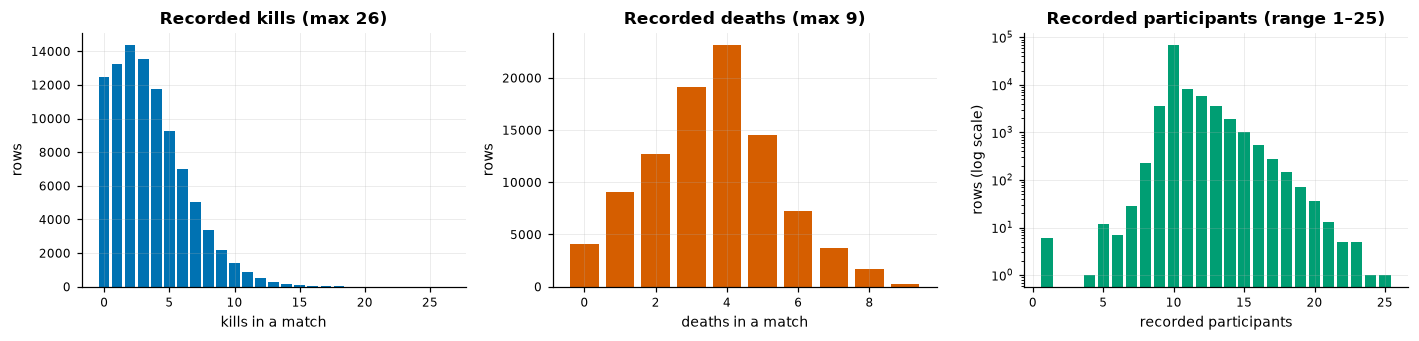

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

k_counts = df["kills"].value_counts().sort_index()
axes[0].bar(k_counts.index, k_counts.values, color=BLUE, width=0.8)
axes[0].set(title="Recorded kills (max 26)", xlabel="kills in a match", ylabel="rows")

d_counts = df["death"].value_counts().sort_index()
axes[1].bar(d_counts.index, d_counts.values, color=VERMILLION, width=0.8)
axes[1].set(title="Recorded deaths (max 9)", xlabel="deaths in a match", ylabel="rows")

p_counts = df["playernb_in_match"].value_counts().sort_index()
axes[2].bar(p_counts.index, p_counts.values, color=GREEN, width=0.8)
axes[2].set_yscale("log")
axes[2].set(title="Recorded participants (range 1–25)", xlabel="recorded participants",
            ylabel="rows (log scale)")

fig.tight_layout()
plt.show()

Recorded kills range from 0 to 26. Maximum deaths are **five in PVP and nine in Ranked and
Unranked**, consistent with classic round-based Siege, where a player can die once per round.
Ubisoft explains this rule in its
[One Life article](https://www.ubisoft.com/en-gb/game/rainbow-six/siege/news-updates/4CK0Vbt3CzbYpBDTYgeDCo/behind-the-wall-series-one-life).
There is no evidence that deaths were clipped, and these classic rules should not be applied to
respawn modes such as Dual Front.

The single one-participant Unranked record and the PvP records without opponents are unusual
recorded states. They may reflect incomplete participation or telemetry, but the file cannot
resolve that. High activity and long kill-count tails also warrant context, rather than automatic
outlier removal.

In [87]:
# Preserve source-row order when a player's timestamps tie.
chrono = df.sort_values(["playerid", "match_ts"], kind="stable")
gap_seconds = chrono.groupby("playerid")["match_ts"].diff().dt.total_seconds()
mixed_ties = (df.groupby(["playerid", "match_ts"])["victory"].nunique() > 1)

print(f"Consecutive-match gaps: {gap_seconds.notna().sum():,}")
print(f"Sub-minute gaps (including ties): {(gap_seconds < 60).sum()}")
print(f"Zero-second gaps: {(gap_seconds == 0).sum()}")
print(f"Tied timestamp groups with different outcomes: {mixed_ties.sum()}")
print("\nGap quantiles (minutes):")
print((gap_seconds.quantile([0.05, 0.25, 0.5, 0.75, 0.95]) / 60).round(1).to_string())

Consecutive-match gaps: 94,894
Sub-minute gaps (including ties): 43
Zero-second gaps: 8
Tied timestamp groups with different outcomes: 3

Gap quantiles (minutes):
0.05      10.6
0.25      20.1
0.50      29.2
0.75     193.7
0.95    3922.7


The median recorded gap is about 29 minutes. There are **43 sub-minute consecutive gaps,
including eight zero-second gaps**, and three tied groups with different outcomes. Short gaps
alone do not prove overlapping gameplay or duplicate events, given the uncertain timestamp
definition. I keep them and use timestamps as the available ordering field; ties require a
sensitivity check for streaks.

| Data-quality finding | Treatment |
|---|---|
| No duplicate rows/pairs; `still_active` is constant within all 840 players | Keep one flag per player; consistency does not establish label validity |
| Combat missing on 153 rows across 43 players | Preserve missing totals and coverage; retain outcomes and activity |
| 43 `draw` and 13 `other` outcomes | Exclude from decided-match denominators; reset streaks |
| 21,667 oversized PVP rosters; 75.6% equal-sized recorded rosters | Consider cumulative backfilling; confirm field meaning |
| One potentially inconsistent teammate outcome among 11 shared matches | Confirm team versus personal outcome definition |
| Different timestamps within shared matches; 43 sub-minute gaps, including eight zero-second gaps | Use available ordering; check sensitivity to ties |
| One-participant Unranked record and five additional PvP records without opponents | Flag unusual recorded states; retain pending clarification |

I retain all source rows. These checks identify limitations, without enough evidence to justify
dropping entire records.

## 3. Win/loss and K/D distributions

For each player, **W/L = wins / losses**, **win rate = wins / decided matches**, and
**K/D = total observed kills / total observed deaths**. K/D uses totals rather than an average of
match-level ratios: ratios with tiny death denominators would otherwise receive disproportionate
weight. Draws and `other` contribute to activity counts but not decided outcomes.

I store ratios with zero denominators as missing rather than inventing a finite value. Combat
ratios are also unavailable when all statistics are missing. The distribution plots include only
finite ratios, with the excluded counts reported below.

In [88]:
outcomes = df.groupby("playerid").agg(
    n_matches=("matchid", "size"),
    n_decided=("is_win", "count"),
    n_wins=("is_win", "sum"),
)
outcomes["n_wins"] = outcomes["n_wins"].astype(int)
outcomes["n_losses"] = (outcomes["n_decided"] - outcomes["n_wins"]).astype(int)
outcomes["win_rate"] = outcomes["n_wins"] / outcomes["n_decided"].replace(0, np.nan)
outcomes["win_loss_ratio"] = outcomes["n_wins"] / outcomes["n_losses"].replace(0, np.nan)

combat_group = df.groupby("playerid")
combat = combat_group.agg(
    n_stat_matches=("kills", "count"),
    avg_kills=("kills", "mean"),
    avg_deaths=("death", "mean"),
)
combat_totals = combat_group[["kills", "death"]].sum(min_count=1).rename(
    columns={"kills": "total_kills", "death": "total_deaths"}
)
combat = combat.join(combat_totals)
combat["kd_ratio"] = combat["total_kills"] / combat["total_deaths"].replace(0, np.nan)

player_performance = outcomes.join(combat)
print("Players with zero losses:", outcomes["n_losses"].eq(0).sum())
print("Players with observed zero total deaths:", combat["total_deaths"].eq(0).sum())
print("Players with entirely missing combat statistics:", combat["n_stat_matches"].eq(0).sum())
print("Excluded from finite W/L plot:", (~np.isfinite(outcomes["win_loss_ratio"])).sum())
print("Excluded from finite K/D plot:", (~np.isfinite(combat["kd_ratio"])).sum())
player_performance[["n_wins", "n_losses", "win_rate", "win_loss_ratio", "kd_ratio"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(3)

Players with zero losses: 48
Players with observed zero total deaths: 6
Players with entirely missing combat statistics: 1
Excluded from finite W/L plot: 48
Excluded from finite K/D plot: 7


,n_wins,n_losses,win_rate,win_loss_ratio,kd_ratio
count,840.000,840.000,840.000,792.000,833.000
mean,54.663,59.239,0.463,0.975,0.898
std,103.242,112.726,0.228,0.853,0.588
min,0.000,0.000,0.000,0.000,0.000
5%,0.000,0.000,0.000,0.000,0.000
25%,2.000,2.000,0.391,0.618,0.524
50%,14.000,13.000,0.489,0.922,0.863
75%,53.250,60.000,0.549,1.145,1.171
95%,257.350,290.300,1.000,2.169,1.805
max,989.000,985.000,1.000,13.000,5.000


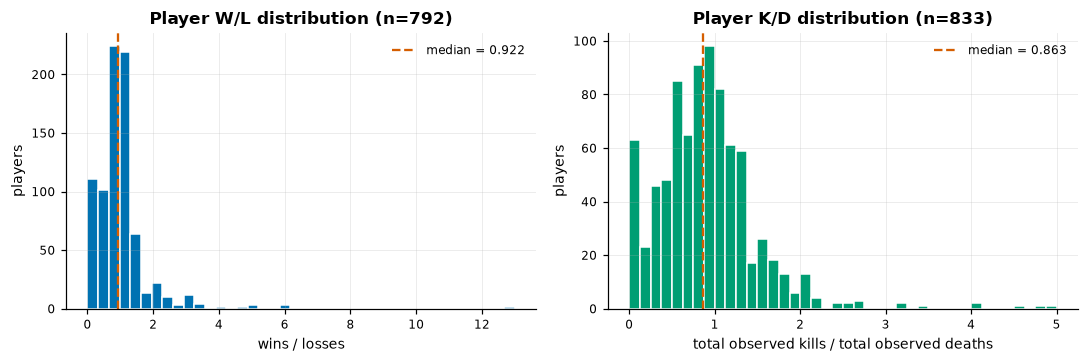

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

wl_finite = outcomes.loc[np.isfinite(outcomes["win_loss_ratio"]), "win_loss_ratio"]
kd_finite = combat.loc[np.isfinite(combat["kd_ratio"]), "kd_ratio"]

axes[0].hist(wl_finite, bins=40, color=BLUE, edgecolor="white")
axes[0].axvline(wl_finite.median(), color=VERMILLION, linestyle="--",
                label=f"median = {wl_finite.median():.3f}")
axes[0].set(title=f"Player W/L distribution (n={len(wl_finite)})",
            xlabel="wins / losses", ylabel="players")
axes[0].legend()

axes[1].hist(kd_finite, bins=40, color=GREEN, edgecolor="white")
axes[1].axvline(kd_finite.median(), color=VERMILLION, linestyle="--",
                label=f"median = {kd_finite.median():.3f}")
axes[1].set(title=f"Player K/D distribution (n={len(kd_finite)})",
            xlabel="total observed kills / total observed deaths", ylabel="players")
axes[1].legend()

fig.tight_layout()
plt.show()

Across all 840 players, median win rate is **0.489** (IQR 0.391–0.549). Median finite W/L is
**0.922**. **48 players** have zero losses and are excluded
from the finite W/L plot. **Seven players** have unavailable K/D: six have observed zero total
deaths, while one has entirely missing combat statistics. Median observed K/D is **0.863**
(IQR 0.524–1.171).

Low match counts make extreme ratios unstable, and missing combat statistics limit coverage.
Different playlist exposure also affects comparability. I would not read K/D alone as overall
Siege contribution: team information and objective play matter too, as illustrated in Ubisoft's
[discussion of performance](https://www.ubisoft.com/en-us/game/rainbow-six/siege/news-updates/4hShcX2HZTG2ttIi3IIN9Y/matchmaking-rating).

## 4. Longest victory and defeat streaks (players with at least 3 matches)

A streak is consecutive wins or losses within one player's timestamp-ordered history. A draw or
`other` resets both streaks. I include all recorded modes, then apply the requested minimum of
three matches to the reported results.

The calculation starts a new run whenever the player or outcome changes, counts each
run, and takes each player's longest win and loss run. This keeps sequences separate by player.

In [90]:
outcome = chrono["victory"].map({"true": "W", "false": "L"}).fillna("X")
new_run = outcome.ne(outcome.shift()) | chrono["playerid"].ne(chrono["playerid"].shift())
run_id = new_run.cumsum()

runs = (pd.DataFrame({"playerid": chrono["playerid"], "outcome": outcome, "run_id": run_id})
        .groupby(["playerid", "outcome", "run_id"], sort=False)
        .size().rename("run_length").reset_index())

max_streaks = (runs.pivot_table(index="playerid", columns="outcome", values="run_length", aggfunc="max")
               .reindex(columns=["W", "L"])
               .rename(columns={"W": "max_victory_streak", "L": "max_defeat_streak"})
               .fillna(0).astype(int))

eligible = max_streaks.join(outcomes["n_matches"])
eligible = eligible[eligible["n_matches"] >= 3]
print(f"players with at least 3 matches: {len(eligible)}")
eligible[["max_victory_streak", "max_defeat_streak"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
).round(2)

players with at least 3 matches: 700


,max_victory_streak,max_defeat_streak
count,700.00,700.00
mean,4.88,5.17
std,2.93,3.17
min,0.00,0.00
25%,3.00,3.00
50%,4.00,5.00
75%,7.00,7.00
95%,10.00,11.00
max,29.00,20.00


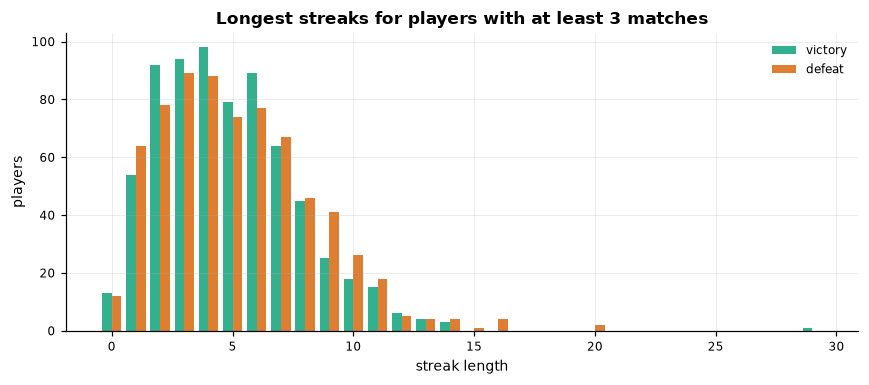

In [91]:
max_streak = int(eligible[["max_victory_streak", "max_defeat_streak"]].to_numpy().max())
bins = np.arange(-0.5, max_streak + 1.5)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist([eligible["max_victory_streak"], eligible["max_defeat_streak"]], bins=bins,
        color=[GREEN, VERMILLION], alpha=0.8, label=["victory", "defeat"])
ax.set(title="Longest streaks for players with at least 3 matches",
       xlabel="streak length", ylabel="players")
ax.legend()
fig.tight_layout()
plt.show()

The three-match rule leaves **700 of 840 players**. Their median longest victory streak is
**4**, and their median longest defeat streak is **5**. The maxima are **29 victories and 20 defeats**.
The player with the 29-win run has 1,342 recorded matches, giving them many more opportunities to
produce a long run than a low-volume player.

For the three tied timestamp groups with different outcomes, checking the possible orderings
did not change the reported 29/20 maxima. Ties still leave the exact sequence ambiguous, so these
are streaks under the available timestamp ordering.

## 5. Player-level feature dataframe

I retain one row per tracked player, including all 840 players regardless of streak eligibility.
The features cover activity volume and regularity, performance, longest streaks and playlist mix.
Counts such as `n_decided` and `n_stat_matches`, plus kill/death totals, make the coverage behind
the ratios visible.

I leave out local-time habits because player locations are unknown, and roster-based social
features because the participant fields need clarification. Recency uses the extract's final
timestamp as a fixed reference, rather than today's date.

In [92]:
REFERENCE_DATE = df["match_ts"].max()

players = df.groupby("playerid").agg(
    first_match=("match_ts", "min"),
    last_match=("match_ts", "max"),
    n_active_days=("match_date", "nunique"),
    still_active=("still_active", "first"),
)
players["observed_activity_span_days"] = (
    (players["last_match"] - players["first_match"]).dt.total_seconds() / 86400
)
players["days_since_last_match"] = (REFERENCE_DATE - players["last_match"]).dt.total_seconds() / 86400

players = players.join(outcomes).join(combat).join(max_streaks)
players["matches_per_active_day"] = players["n_matches"] / players["n_active_days"]
players["median_gap_days"] = (gap_seconds / 86400).groupby(chrono["playerid"]).median()
players["ranked_share"] = df["gamemode"].eq("PVP_RANKED").groupby(df["playerid"]).mean()
players["n_gamemodes"] = df.groupby("playerid")["gamemode"].nunique()

FEATURE_COLUMNS = [
    "still_active", "first_match", "last_match",
    "n_matches", "n_active_days", "observed_activity_span_days", "days_since_last_match",
    "matches_per_active_day", "median_gap_days",
    "n_decided", "n_wins", "n_losses", "win_rate", "win_loss_ratio",
    "n_stat_matches", "total_kills", "total_deaths", "avg_kills", "avg_deaths", "kd_ratio",
    "max_victory_streak", "max_defeat_streak", "ranked_share", "n_gamemodes",
]
players = players[FEATURE_COLUMNS]
players.to_csv(OUTPUT_DIR / "players_features.csv")
print(f"Saved {OUTPUT_DIR / 'players_features.csv'}: {players.shape[0]} players x {players.shape[1]} columns")
print("Recency reference:", REFERENCE_DATE)

Saved outputs/players_features.csv: 840 players x 24 columns
Recency reference: 2026-03-03 13:54:20.190000+00:00


In [93]:
print("Unavailable feature values:")
print(players.isna().sum().loc[lambda s: s > 0].to_string())
players[["n_matches", "n_decided", "n_stat_matches", "total_kills", "total_deaths",
         "win_rate", "kd_ratio", "days_since_last_match"]].head()

Unavailable feature values:
median_gap_days    92
win_loss_ratio     48
total_kills         1
total_deaths        1
avg_kills           1
avg_deaths          1
kd_ratio            7


,n_matches,n_decided,n_stat_matches,total_kills,total_deaths,win_rate,kd_ratio,days_since_last_match
playerid,,,,,,,,
00229b3f-4e74-4e8d-b6ce-37df9a851cb7,24,24,24,50.0,111.0,0.541667,0.450450,247.040264
002bbbc5-5078-436e-ad52-e8af9bdbd4a8,119,119,119,437.0,538.0,0.420168,0.812268,1.855695
00460d80-da57-4551-9cdd-f292ea93a66a,4,4,4,14.0,12.0,0.750000,1.166667,39.611540
0051177e-b731-4c60-a75a-9a7e8fba7fde,111,111,111,185.0,312.0,0.441441,0.592949,92.468571
007775a1-5302-4c7f-a366-a3e31b57c978,402,401,397,1588.0,1660.0,0.503741,0.956627,74.246791


The dataframe contains **840 rows and 24 columns**, with `playerid` as its index. The CSV adds
that index as an identifier column. The supplied flag and first/last timestamps are retained as
context; they are not all predictive inputs.

`observed_activity_span_days` measures first-to-last recorded activity, not account tenure.
`n_active_days` counts distinct UTC dates, and `median_gap_days` measures typical spacing between
recorded matches. `ranked_share` and `n_gamemodes` describe playlist exposure.

Missing values remain interpretable: one-match players have no gap, zero denominators have no
finite ratio, and the entirely unobserved player has missing combat totals and averages. The
coverage counts distinguish these cases. Recency is descriptive: the endpoint is a reference
date, **not a confirmed label-assessment date**. Full-history features would need to be rebuilt
at a prediction cutoff before modelling future churn.

## 6. How I would approach churn prediction

### Exploratory classification of the supplied flag

This experiment classifies the supplied activity flag from recorded player histories.
Because the flag's definition and assessment date are unknown, these scores do not establish
future churn prediction.

I use one row per player and define **inactive as the positive class**. The stratified 80/10/10
split preserves class proportions: training fits the pipelines, validation selects the model by
ROC-AUC, and test evaluates only the selected, already-fitted pipeline. Parameters are fixed,
and imputation and scaling learn from training data only. The majority classifier provides a
baseline, logistic regression a simple linear model, and Random Forest a nonlinear comparison.

Identifiers, raw timestamps, the activity flag and recency are excluded from the inputs.
Excluding recency does not resolve the timing issue: other features still describe complete
recorded histories. The recency examples below reinforce the need to clarify the flag's definition
and coverage, rather than automatically declaring the labels wrong.

In [94]:
active_recency = players.loc[players["still_active"], "days_since_last_match"]
inactive_recency = players.loc[~players["still_active"], "days_since_last_match"]
print(f"Longest recency among players flagged active: {active_recency.max():.1f} days")
print(f"Shortest recency among players flagged inactive: {inactive_recency.min() * 24:.1f} hours")

Longest recency among players flagged active: 359.5 days
Shortest recency among players flagged inactive: 14.7 hours


In [95]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

MODEL_FEATURES = [
    "n_matches", "n_active_days", "observed_activity_span_days", "median_gap_days",
    "win_rate", "kd_ratio", "max_victory_streak", "max_defeat_streak",
    "ranked_share", "n_gamemodes",
]
X = players[MODEL_FEATURES]
y = (~players["still_active"]).astype(int)

X_train, X_reserved, y_train, y_reserved = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_reserved, y_reserved, test_size=0.50, stratify=y_reserved, random_state=42
)

split_summary = pd.DataFrame({
    "players": [len(X_train), len(X_validation), len(X_test)],
    "inactive_proportion": [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=["training", "validation", "test"])
split_summary.round(3)

,players,inactive_proportion
training,672,0.580
validation,84,0.583
test,84,0.583


In [96]:
models = {
    "majority baseline": Pipeline([
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "logistic regression": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ]),
    "random forest": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=100, min_samples_leaf=3,
                                         random_state=42)),
    ]),
}

validation_rows = []
for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    # Classes are [0, 1]; column 1 is the probability of being inactive.
    validation_probabilities = pipeline.predict_proba(X_validation)[:, 1]
    validation_rows.append({
        "model": model_name,
        "ROC-AUC": roc_auc_score(y_validation, validation_probabilities),
        "AP": average_precision_score(y_validation, validation_probabilities),
    })

validation_scores = pd.DataFrame(validation_rows).set_index("model")
validation_scores.round(3)

,ROC-AUC,AP
model,,
majority baseline,0.500,0.583
logistic regression,0.835,0.806
random forest,0.789,0.811


In [97]:
selected_model_name = validation_scores["ROC-AUC"].idxmax()
selected_pipeline = models[selected_model_name]
print("Selected by validation ROC-AUC:", selected_model_name)

# Keep the training fit; do not refit or tune using the test set.
test_probabilities = selected_pipeline.predict_proba(X_test)[:, 1]
test_predictions = selected_pipeline.predict(X_test)
test_scores = pd.Series({
    "ROC-AUC": roc_auc_score(y_test, test_probabilities),
    "AP": average_precision_score(y_test, test_probabilities),
    "accuracy (default threshold)": accuracy_score(y_test, test_predictions),
})
test_scores.round(3).to_frame("test_score")

Selected by validation ROC-AUC: logistic regression


,test_score
ROC-AUC,0.734
AP,0.759
accuracy (default threshold),0.679


Both fitted models improve on the validation baseline: logistic regression reaches **0.835
ROC-AUC / 0.806 AP** and Random Forest **0.789 / 0.811**, versus **0.500 / 0.583** for the majority
classifier. I select logistic regression because it has the highest validation ROC-AUC, although
Random Forest has slightly higher AP. On the untouched test set, the selected training-fitted
pipeline achieves **0.734 ROC-AUC, 0.759 AP and 67.9% accuracy** at the default 0.5 threshold.
Each evaluation set contains only **84 players**, so small differences, especially the AP gap,
should be interpreted cautiously, and one split gives limited evidence about generalisation.
These scores describe predictive associations with the supplied flag, not causes of churn or
validated future inactivity prediction.

### Evaluating future inactivity prediction

For future prediction, I could build features from the **90 days before a cutoff T** and define
inactivity as **no match in the following 30 days**, provided match coverage is complete. These
windows are illustrative, and this derived target would be separate from the supplied flag.
I would agree the eligible population and windows with the retention team; inactivity need not
mean permanent churn.

I would use only information available at T and fully observed future outcome windows. Training,
validation and test periods would be chronological: learn from earlier cutoffs, select the model
and intervention threshold on a later validation period, then evaluate once on the latest test
period. Training outcome windows must finish before the next evaluation period. All features would
be rebuilt within the observation window; removing recency alone cannot fix full-history leakage.

With inactivity as the positive class, **ROC-AUC** measures ranking discrimination and
**average precision (AP)** summarises precision weighted by recall increments, rather than
trapezoidal PR-AUC. For an intervention, **precision/recall at a chosen threshold** shows what
share of contacted players meet the target and what share of target players are reached.
I would select that threshold on validation data using contact capacity and intervention costs;
the exploratory comparison above uses the models' default decision threshold for test accuracy.